# Stylized Facts about Electricity Prices & Residual Load

In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from diagnostic_test import Diagnostics
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from transformations import transform_prices

In [2]:
# init instance of diagnostics
diagnostics = Diagnostics()

## Loading & Plotting Data

In [3]:
prices = pd.read_csv("../data/prices.csv", index_col=1).iloc[:,1:]
rl_f = pd.read_csv("../data/rl_id.csv", index_col=1).iloc[:,1:]

prices.index = pd.to_datetime(prices.index)
rl_f.index = pd.to_datetime(rl_f.index)

prices = prices[~prices.index.duplicated(keep='last')]
rl_f = rl_f[~rl_f.index.duplicated(keep='last')]

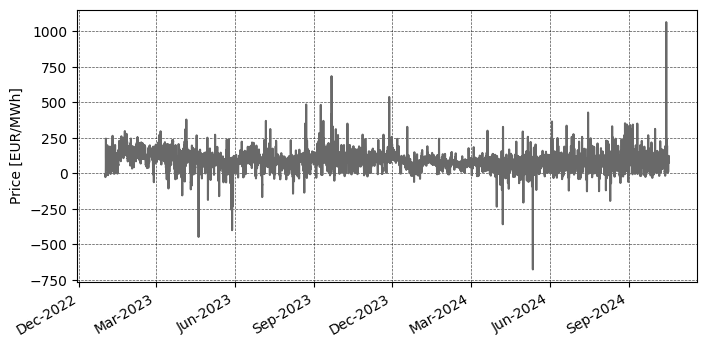

In [4]:
# Plot the time series
plt.figure(figsize=(8, 4), facecolor='white')  # Set background to white
plt.plot(prices.index, prices['ID3_price'], color='dimgray')  # Use black for the line
# plt.title("Day-Ahead Electricity Prices", fontsize=12)
plt.ylabel("Price [EUR/MWh]", fontsize=10)

# Set x-axis to display months and years, spaced appropriately
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Every 3 months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))  # Display Month-Year

# Auto-format dates for better readability
plt.gcf().autofmt_xdate()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# Remove grey background and ensure white figure
plt.gca().set_facecolor('white')

plt.savefig('../images/ID/id3_price.png')
plt.show()

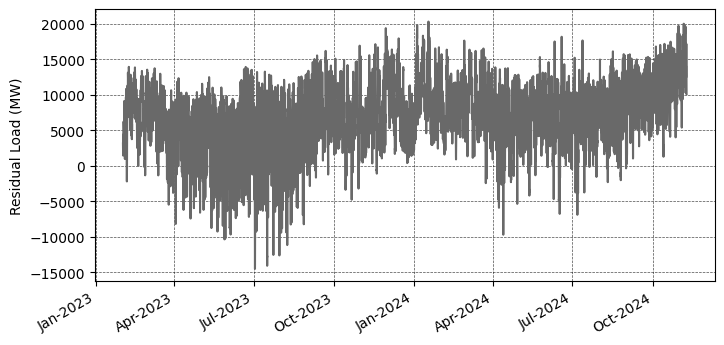

In [5]:
# Plot the time series
plt.figure(figsize=(8, 4), facecolor='white')  # Set background to white
plt.plot(rl_f.index, rl_f, color='dimgray')  # Use dimgray for the line
# plt.title("Residual Load", fontsize=12)
plt.ylabel("Residual Load (MW)", fontsize=10)

# Set x-axis to display months and years, spaced appropriately
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Every 3 months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))  # Display Month-Year

# Auto-format dates for better readability
plt.gcf().autofmt_xdate()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# Remove grey background and ensure white figure
plt.gca().set_facecolor('white')
plt.show()


# Descriptive Stats

In [6]:
# Apply the function to your DataFrame
descriptive_stats = diagnostics.descriptive_statistics(pd.DataFrame(prices['ID3_price']))

Descriptive Statistics:

╒═══════════╤═════════╤════════╤═══════════╤═════════╤═══════════════════╤══════════╤═══════════════════╤════════╤════════════╤════════════╕
│           │   count │   Mean │   Std Dev │     Min │   25th Percentile │   Median │   75th Percentile │    Max │   Skewness │   Kurtosis │
╞═══════════╪═════════╪════════╪═══════════╪═════════╪═══════════════════╪══════════╪═══════════════════╪════════╪════════════╪════════════╡
│ ID3_price │   15742 │ 85.828 │    55.804 │ -675.83 │            61.282 │   88.775 │           112.005 │ 1064.8 │      0.515 │     22.381 │
╘═══════════╧═════════╧════════╧═══════════╧═════════╧═══════════════════╧══════════╧═══════════════════╧════════╧════════════╧════════════╛


In [7]:
descriptive_stats = diagnostics.descriptive_statistics(rl_f)

Descriptive Statistics:

╒════╤═════════╤═════════╤═══════════╤══════════╤═══════════════════╤══════════╤═══════════════════╤═════════╤════════════╤════════════╕
│    │   count │    Mean │   Std Dev │      Min │   25th Percentile │   Median │   75th Percentile │     Max │   Skewness │   Kurtosis │
╞════╪═════════╪═════════╪═══════════╪══════════╪═══════════════════╪══════════╪═══════════════════╪═════════╪════════════╪════════════╡
│ rl │   15527 │ 6959.99 │   4605.83 │ -14493.5 │           4459.02 │   7458.7 │           9916.92 │ 20312.8 │     -0.646 │      1.028 │
╘════╧═════════╧═════════╧═══════════╧══════════╧═══════════════════╧══════════╧═══════════════════╧═════════╧════════════╧════════════╛


## Season-wise Plots

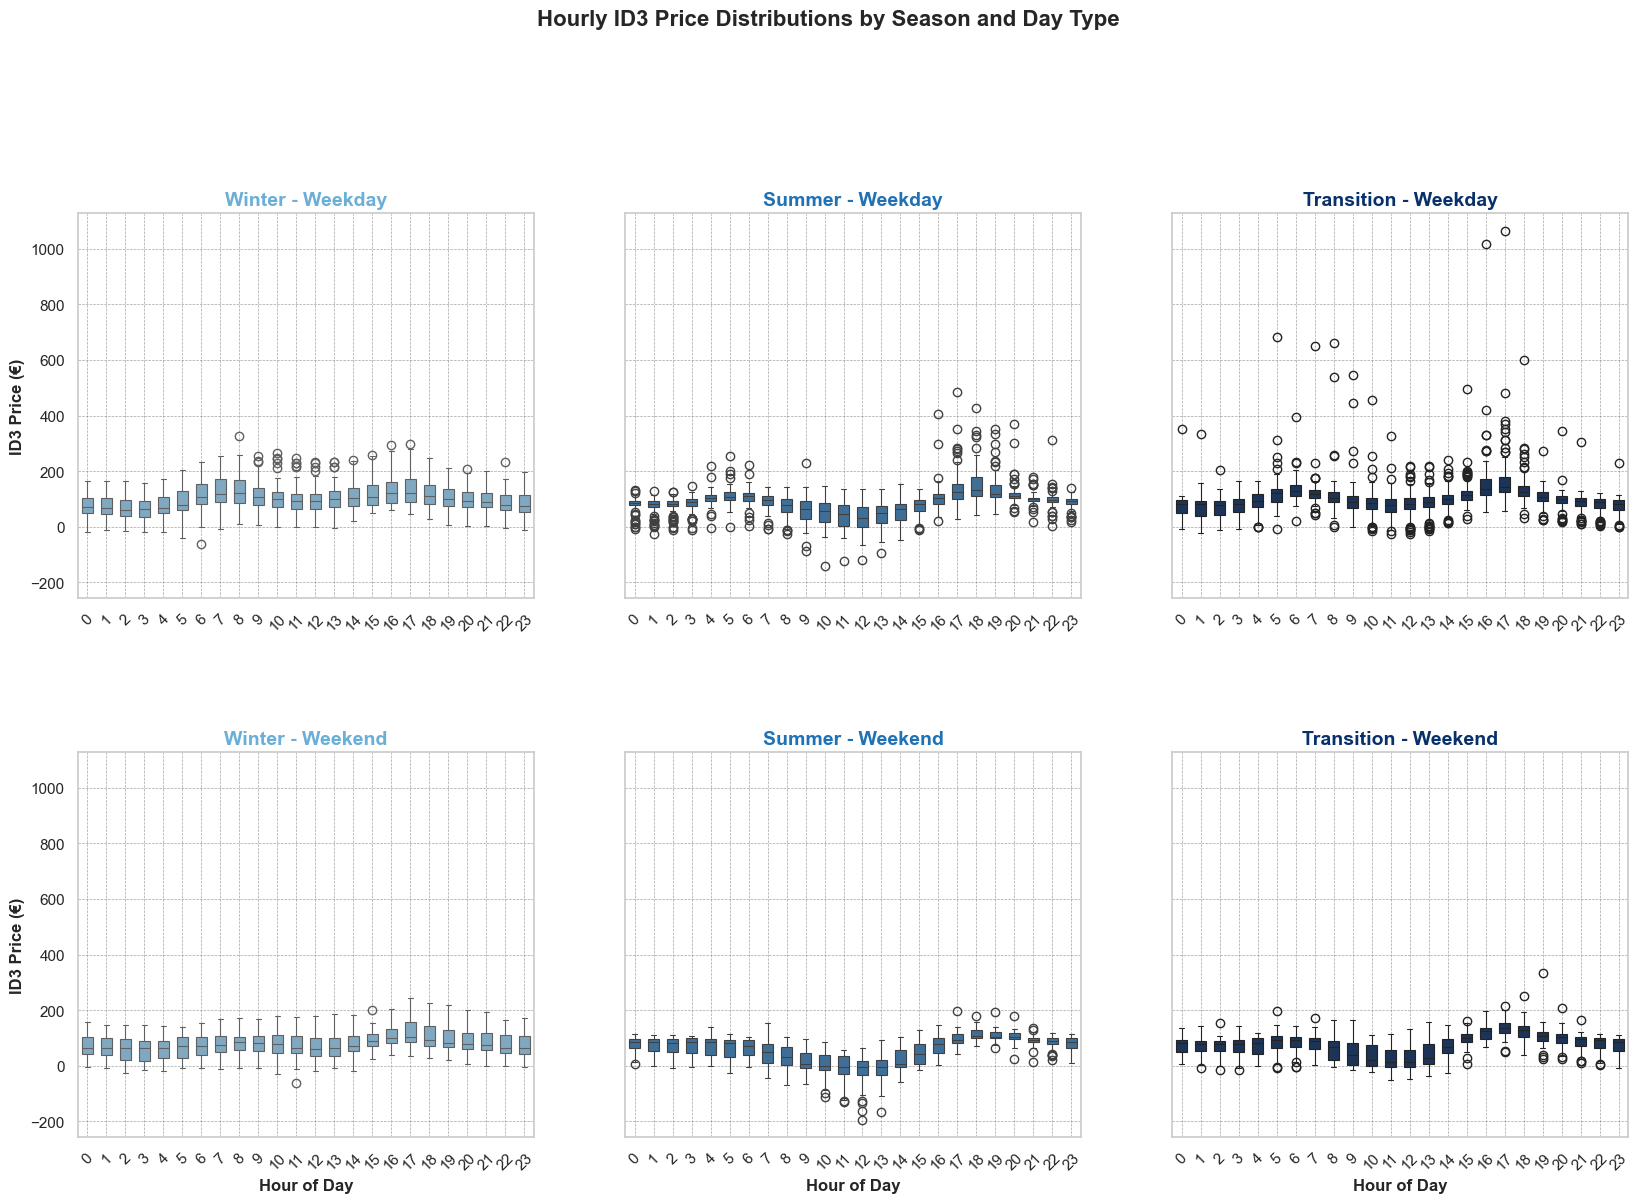

In [8]:
prices['hour'] = prices.index.hour  # Extract hour from DateTime index
prices['day_of_week'] = prices.index.weekday  # Extract day of the week

# Create hourly dummies
hour_dummies = pd.get_dummies(prices['hour'], prefix='hour', drop_first=True)
prices = pd.concat([prices, hour_dummies], axis=1)

# Create a weekend dummy
prices['weekend'] = np.where(prices['day_of_week'] >= 5, 1, 0)

# Seasonal dummies
prices['season'] = np.where(prices.index.month.isin([12, 1, 2]), 'Winter',
                     np.where(prices.index.month.isin([7, 8]), 'Summer',
                     np.where(prices.index.month.isin([9, 10, 11]), 'Transition', 'Other')))

# Create season dummies
season_dummies = pd.get_dummies(prices['season'], prefix='season', drop_first=True)
prices = pd.concat([prices, season_dummies], axis=1)

# Prepare for plotting
prices['weekday_weekend'] = np.where(prices['weekend'] == 1, 'Weekend', 'Weekday')

# Set up plot aesthetics
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=True)

# Define seasons and weekend/weekday combinations
seasons = ['Winter', 'Summer', 'Transition']
types = ['Weekday', 'Weekend']
colors = ['#6baed6', '#2171b5', '#08306b']  # Custom color palette for each season

# Plot each season-weekday/weekend combination in a separate subplot
for i, season in enumerate(seasons):
    for j, day_type in enumerate(types):
        ax = axes[j, i]
        subset = prices[(prices['season'] == season) & (prices['weekday_weekend'] == day_type)]
        
        # Box plot with customized appearance
        sns.boxplot(data=subset, x='hour', y='ID3_price', ax=ax, showfliers=True,
                    color=colors[i], saturation=0.6, width=0.6, linewidth=0.8)
        
        # Titles and labels
        ax.set_title(f'{season} - {day_type}', fontsize=14, weight='bold', color=colors[i])
        ax.set_xlabel('Hour of Day', fontsize=12, weight='bold')
        ax.set_ylabel('ID3 Price (€)', fontsize=12, weight='bold')
        
        # Customize ticks and grid
        ax.tick_params(axis='x', rotation=45)
        ax.grid(visible=True, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
        
        # Show only relevant y-axis labels
        if i > 0:
            ax.set_ylabel('')
        if j < 1:
            ax.set_xlabel('')

# Adjust layout for better spacing
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.suptitle('Hourly ID3 Price Distributions by Season and Day Type', 
             fontsize=16, weight='bold', y=1.05)
plt.show()


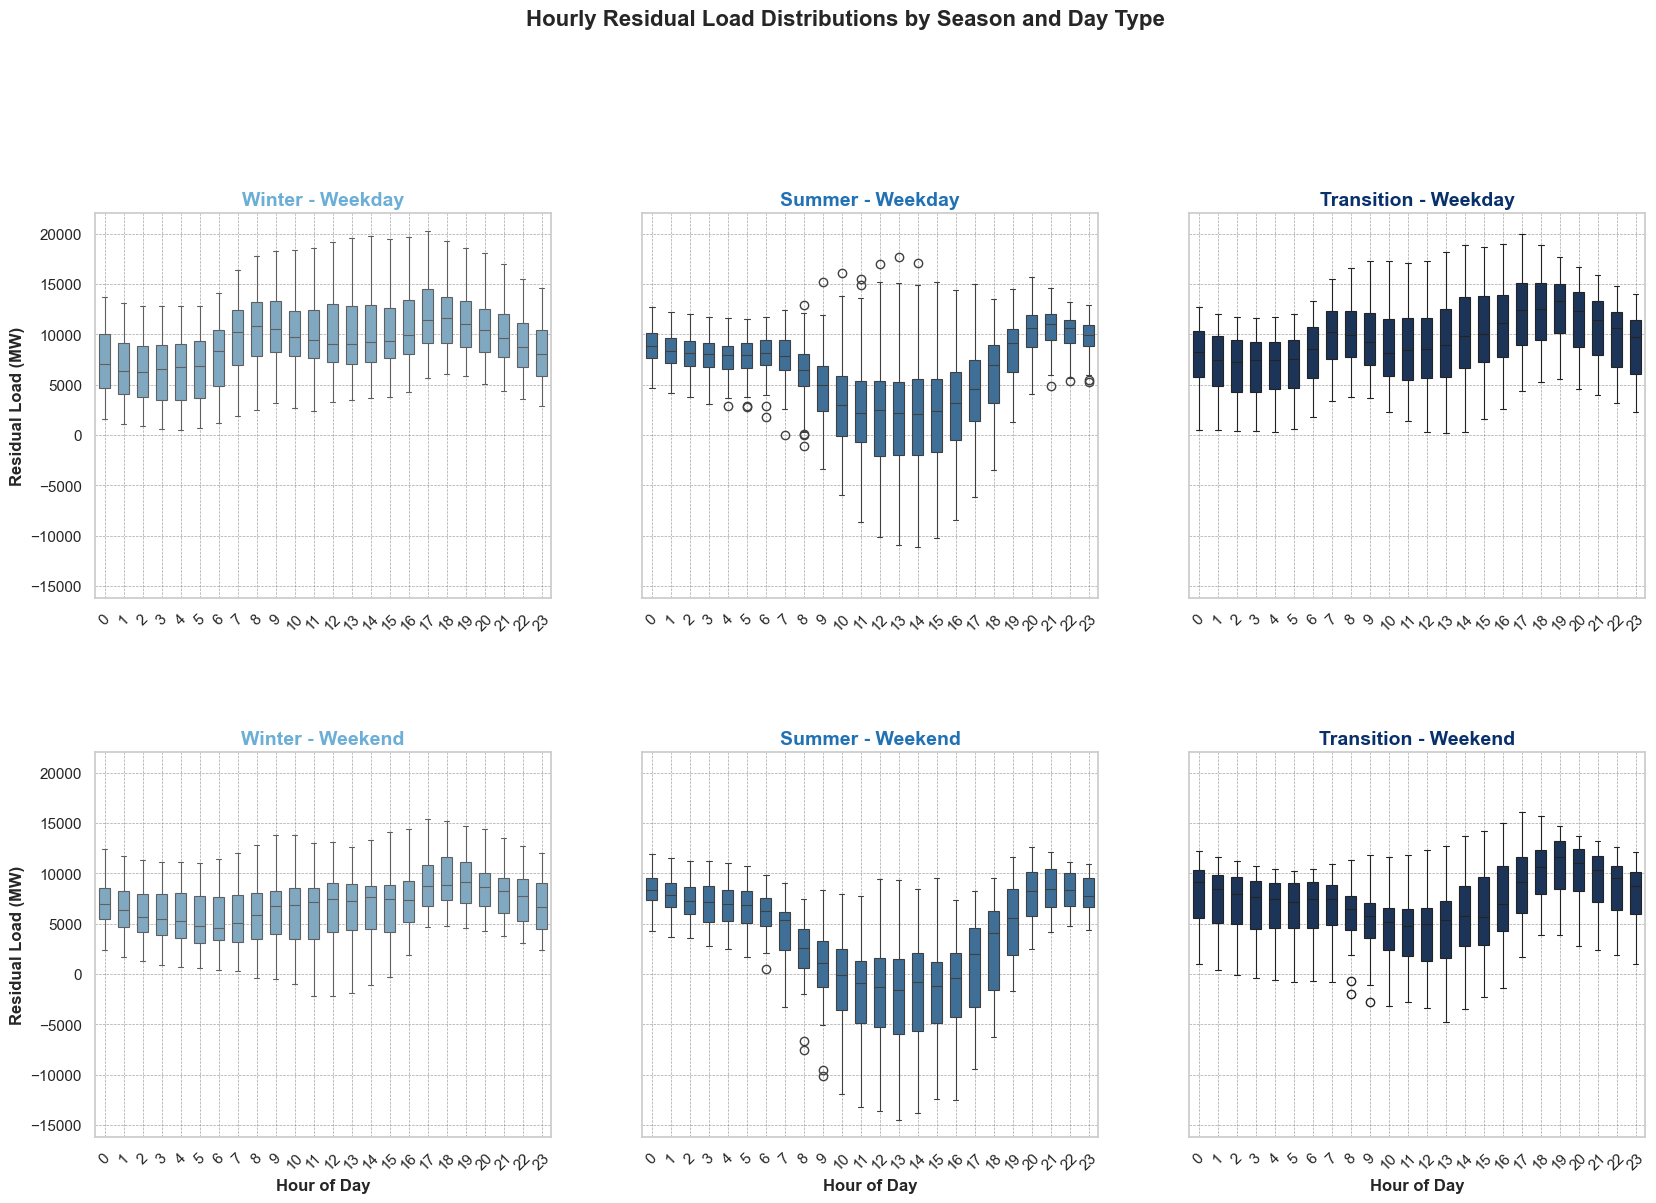

In [9]:
rl_f['hour'] = rl_f.index.hour  # Extract hour from DateTime index
rl_f['day_of_week'] = rl_f.index.weekday  # Extract day of the week

# Create hourly dummies
hour_dummies = pd.get_dummies(rl_f['hour'], prefix='hour', drop_first=True)
rl_f = pd.concat([rl_f, hour_dummies], axis=1)

# Create a weekend dummy
rl_f['weekend'] = np.where(rl_f['day_of_week'] >= 5, 1, 0)

# Seasonal dummies
rl_f['season'] = np.where(rl_f.index.month.isin([12, 1, 2]), 'Winter',
                     np.where(rl_f.index.month.isin([7, 8]), 'Summer',
                     np.where(rl_f.index.month.isin([9, 10, 11]), 'Transition', 'Other')))

# Create season dummies
season_dummies = pd.get_dummies(rl_f['season'], prefix='season', drop_first=True)
rl_f = pd.concat([rl_f, season_dummies], axis=1)

# Prepare for plotting
rl_f['weekday_weekend'] = np.where(rl_f['weekend'] == 1, 'Weekend', 'Weekday')

# Set up plot aesthetics
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=True)

# Define seasons and weekend/weekday combinations
seasons = ['Winter', 'Summer', 'Transition']
types = ['Weekday', 'Weekend']
colors = ['#6baed6', '#2171b5', '#08306b']  # Custom color palette for each season

# Plot each season-weekday/weekend combination in a separate subplot
for i, season in enumerate(seasons):
    for j, day_type in enumerate(types):
        ax = axes[j, i]
        subset = rl_f[(rl_f['season'] == season) & (rl_f['weekday_weekend'] == day_type)]
        
        # Box plot with customized appearance
        sns.boxplot(data=subset, x='hour', y='rl', ax=ax, showfliers=True,
                    color=colors[i], saturation=0.6, width=0.6, linewidth=0.8)
        
        # Titles and labels
        ax.set_title(f'{season} - {day_type}', fontsize=14, weight='bold', color=colors[i])
        ax.set_xlabel('Hour of Day', fontsize=12, weight='bold')
        ax.set_ylabel('Residual Load (MW)', fontsize=12, weight='bold')
        
        # Customize ticks and grid
        ax.tick_params(axis='x', rotation=45)
        ax.grid(visible=True, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
        
        # Show only relevant y-axis labels
        if i > 0:
            ax.set_ylabel('')
        if j < 1:
            ax.set_xlabel('')

# Adjust layout for better spacing
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.suptitle('Hourly Residual Load Distributions by Season and Day Type', 
             fontsize=16, weight='bold', y=1.05)
plt.show()


# Diagnostics

## Stationarity Test

In [10]:
# 1. Stationarity Test - Augmented Dickey-Fuller Test
print("ADF Test for ID3 Price Series")
diagnostics.adf_test(prices['ID3_price'])

print()

print("ADF Test for RDL Series")
diagnostics.adf_test(rl_f['rl'])

ADF Test for ID3 Price Series
ADF Statistic: -11.77867718546247
p-value: 1.0474955123698993e-21
Stationary

ADF Test for RDL Series
ADF Statistic: -8.874301498013553
p-value: 1.3711576524142463e-14
Stationary


{'ADF Statistic': -8.874301498013553,
 'p-value': 1.3711576524142463e-14,
 'Stationarity': 'Stationary'}

## Normality Test

Shapiro-Wilk Test:
Statistic: 0.8923, p-value: 0.0000
Residuals not normal.

Anderson-Darling Test:
Statistic: 231.4432
Significance Level: 15.0%, Critical Value: 0.5760
Significance Level: 10.0%, Critical Value: 0.6560
Significance Level: 5.0%, Critical Value: 0.7870
Significance Level: 2.5%, Critical Value: 0.9180
Significance Level: 1.0%, Critical Value: 1.0920


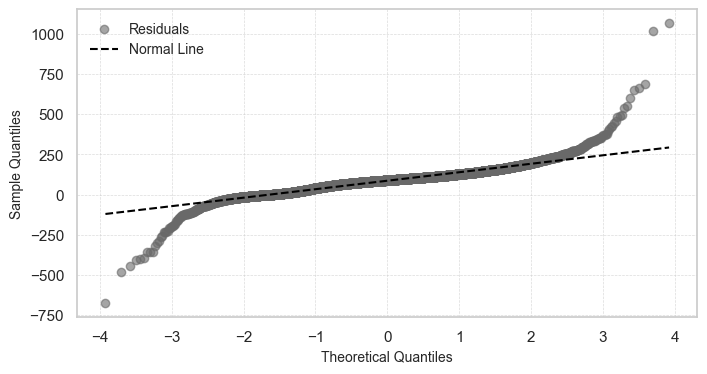

{'Shapiro-Wilk': {'statistic': 0.8922610878944397, 'p-value': 0.0},
 'Anderson-Darling': {'statistic': 231.44315621981332,
  'critical_values': [0.576, 0.656, 0.787, 0.918, 1.092],
  'significance_levels': [15.0, 10.0, 5.0, 2.5, 1.0]}}

In [11]:
diagnostics.normality_test(prices['ID3_price'], path='../images/ID/id3_price_normality.png')

Shapiro-Wilk Test:
Statistic: 0.9758, p-value: 0.0000
Residuals not normal.

Anderson-Darling Test:
Statistic: 94.3862
Significance Level: 15.0%, Critical Value: 0.5760
Significance Level: 10.0%, Critical Value: 0.6560
Significance Level: 5.0%, Critical Value: 0.7870
Significance Level: 2.5%, Critical Value: 0.9180
Significance Level: 1.0%, Critical Value: 1.0920


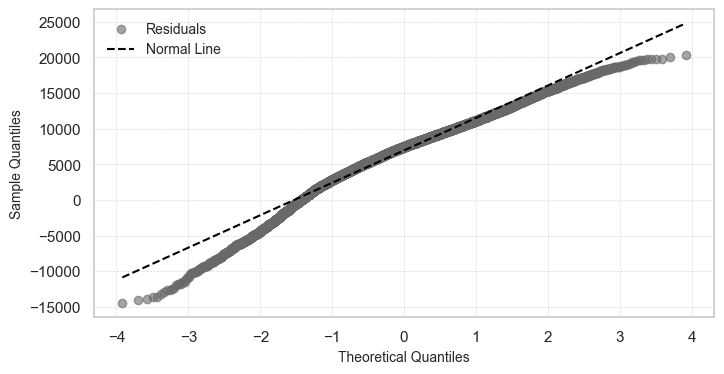

{'Shapiro-Wilk': {'statistic': 0.9758167266845703,
  'p-value': 9.80908925027372e-45},
 'Anderson-Darling': {'statistic': 94.386247191027,
  'critical_values': [0.576, 0.656, 0.787, 0.918, 1.092],
  'significance_levels': [15.0, 10.0, 5.0, 2.5, 1.0]}}

In [12]:
diagnostics.normality_test(rl_f['rl'])

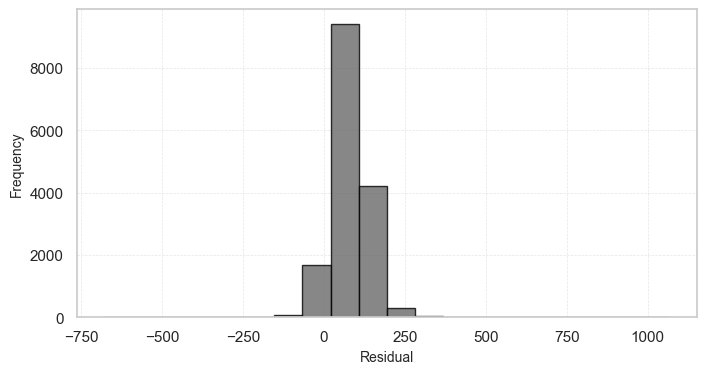

In [13]:
diagnostics.plot_histogram(prices['ID3_price'], title='', path='../images/ID/id3_price_hist.png')

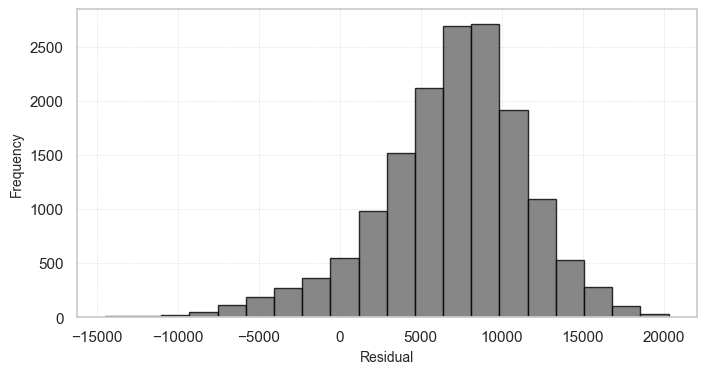

In [14]:
diagnostics.plot_histogram(rl_f['rl'], title='')

## Serial Correlations

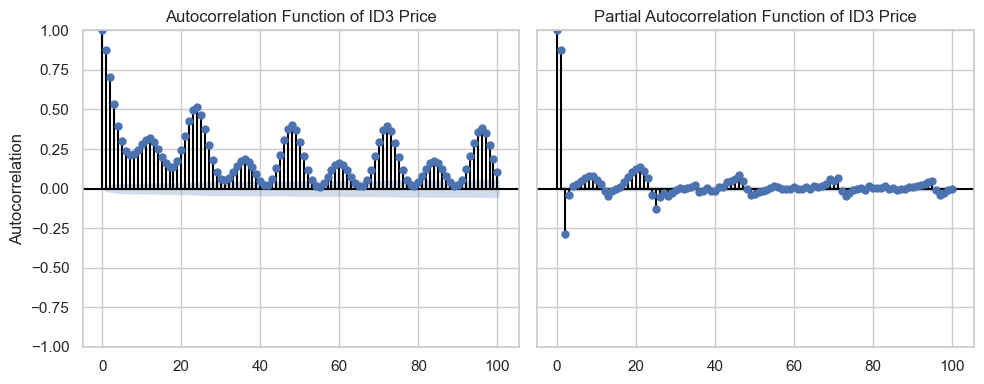

In [15]:
# 3. Autocorrelation and Partial Autocorrelation - ACF and PACF
diagnostics.plot_acf_pacf(prices['ID3_price'], 100, acf_title="Autocorrelation Function of ID3 Price", pacf_title="Partial Autocorrelation Function of ID3 Price", path='../images/ID/id3_price_corr.png')

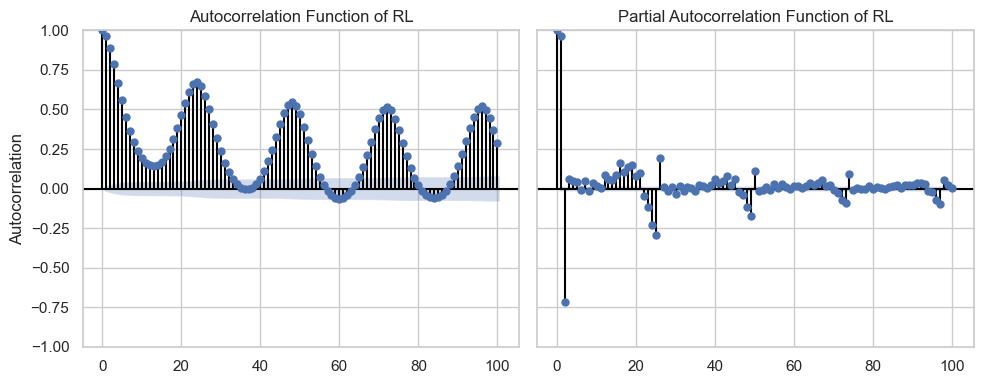

In [16]:
# 3. Autocorrelation and Partial Autocorrelation - ACF and PACF
diagnostics.plot_acf_pacf(rl_f['rl'], 100, acf_title="Autocorrelation Function of RL", pacf_title="Partial Autocorrelation Function of RL")

## Mean Reversion

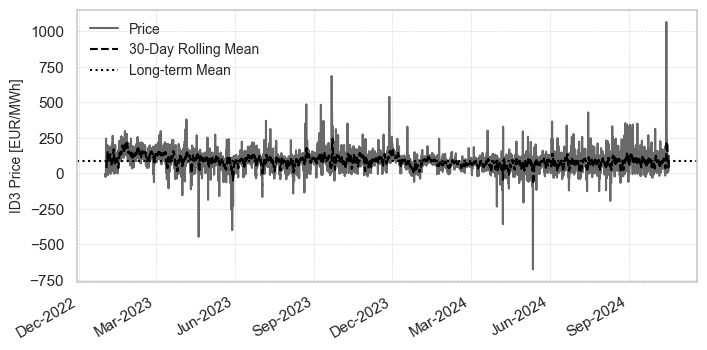

In [17]:
# Compute rolling mean and long-term mean
rolling_mean = prices['ID3_price'].rolling(window=30).mean()
mean_price = prices['ID3_price'].mean()

# Plot mean reversion test
plt.figure(figsize=(8, 4), facecolor='white')
plt.plot(prices.index, prices['ID3_price'], color='dimgray', label="Price")  # Use dimgray for consistency
plt.plot(prices.index, rolling_mean, color='black', linestyle='--', label="30-Day Rolling Mean")
plt.axhline(y=mean_price, color='black', linestyle=':', linewidth=1.5, label="Long-term Mean")

# Title and labels
# plt.title("Mean Reversion Test", fontsize=12)
plt.ylabel("ID3 Price [EUR/MWh]", fontsize=10)

# Set x-axis to display months and years
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Every 3 months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))  # Display Month-Year

# Auto-format dates for better readability
plt.gcf().autofmt_xdate()

# Grid and legend
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend(fontsize=10, frameon=False, loc="upper left")

# Remove grey background and ensure white figure
plt.gca().set_facecolor('white')

plt.savefig('../images/ID/id3_price_mean_reversion.png')
plt.show()


## Volatility Clustering

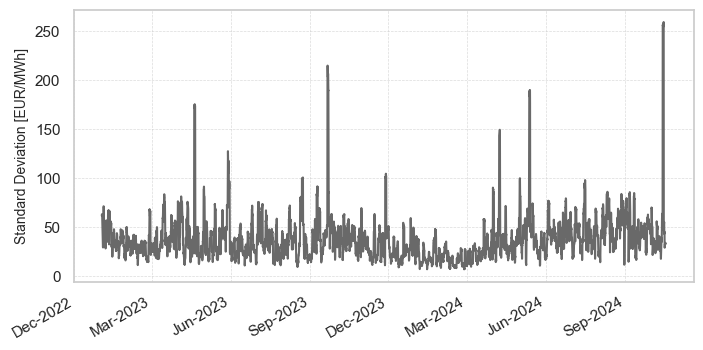

In [18]:
# Compute rolling standard deviation
rolling_std = prices['ID3_price'].rolling(window=30).std()

# Plot volatility clustering
plt.figure(figsize=(8, 4), facecolor='white')
plt.plot(prices.index, rolling_std, color='dimgray')  # Use dimgray for consistency
# plt.title("Rolling Standard Deviation (Volatility Clustering)", fontsize=12)
plt.ylabel("Standard Deviation [EUR/MWh]", fontsize=10)

# Set x-axis to display months and years
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Every 3 months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))  # Display Month-Year

# Auto-format dates for better readability
plt.gcf().autofmt_xdate()

# Grid formatting
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# Remove grey background and ensure white figure
plt.gca().set_facecolor('white')

plt.savefig('../images/ID/id3_price_vol_clustering.png')
plt.show()


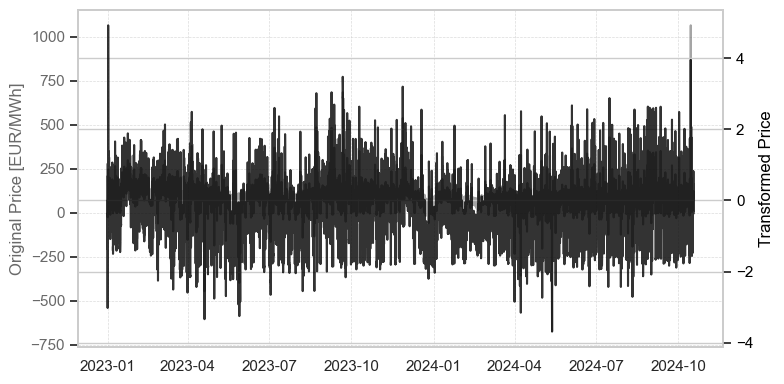

In [19]:
# Apply the area hyperbolic sine transformation
prices_hyp_sin_transform, median, mad = transform_prices(prices['ID3_price'])

# Plot original and transformed prices with dual y-axis
fig, ax1 = plt.subplots(figsize=(8, 4), facecolor='white')

# Primary y-axis for original prices
ax1.plot(prices.index, prices['ID3_price'], label='Original Price', color='dimgray', alpha=0.6)
ax1.set_ylabel('Original Price [EUR/MWh]', color='dimgray')
ax1.tick_params(axis='y', labelcolor='dimgray')

# Secondary y-axis for transformed prices
ax2 = ax1.twinx()
ax2.plot(prices.index, prices_hyp_sin_transform, label='Area Hyperbolic Sine Transformed Price', color='black', alpha=0.8)
ax2.set_ylabel('Transformed Price', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Title and labels
# fig.suptitle("Original and Area Hyperbolic Sine Transformed Electricity Prices", fontsize=12)

# Grid formatting
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# Remove grey background
ax1.set_facecolor('white')
ax2.set_facecolor('white')

fig.tight_layout()

plt.savefig('../images/ID/id3_price_arc_sine_transformed.png')
plt.show()

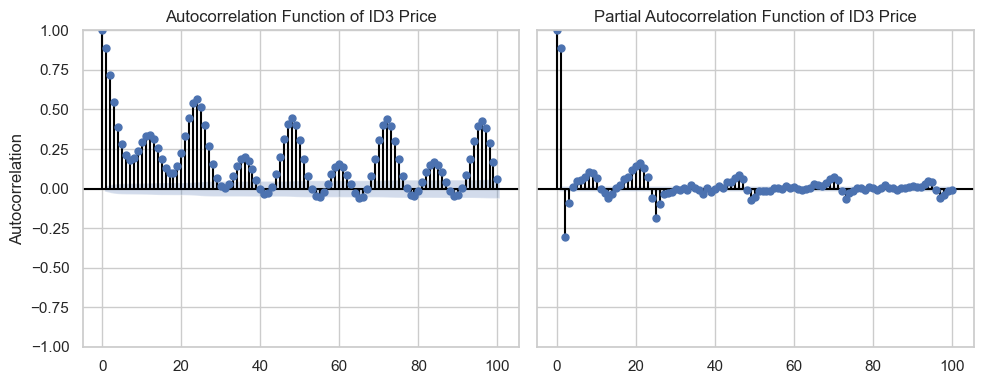

In [20]:
# 3. Autocorrelation and Partial Autocorrelation - ACF and PACF
diagnostics.plot_acf_pacf(prices_hyp_sin_transform.dropna(), 100, acf_title="Autocorrelation Function of ID3 Price", pacf_title="Partial Autocorrelation Function of ID3 Price", path='../images/ID/id3_price_AHS_corr.png')